# Telco Churn Analysis

## Business Problem Understanding

**Q. What is Customer Churn?**

***A.*** Customer churn refers to customers who discontinue or stop using a company’s service during a given period. In the telecom industry, churn represents subscriber loss and directly impacts recurring revenue.

**Q. Why is Churn Important?**

***A.*** Telecommunication companies operate on subscription-based revenue models. High churn leads to revenue loss, increased customer acquisition costs, and reduced profitability. Understanding churn enables companies to implement proactive retention strategies.

## Project Objective

**The objective of this analysis is to:**

* Identify key factors driving customer churn
* Detect customer segments with high churn risk
* Develop data-driven customer retention recommendations

## Analysis Objectives

* Understand customer behaviour patterns
* Compare churned vs retained customers
* Identify factors influencing churn
* Segment customers based on risk level (high risk vs loyal)
* Provide business recommendations to reduce churn

## Key Business Questions

* What percentage of customers churn?
* Does contract type influence churn?
* Are higher monthly charges linked to churn?
* Do newer customers churn more than long-term customers?
* Which customers are most at risk?

## Analytical Approach

* Data loading and inspection
* Data cleaning
* Exploratory analysis
* KPI calculation
* Customer segmentation
* Visualization and insights

## Data Loading and Initial Exploration

In [2]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading Dataset

df = pd.read_csv("../01 Raw Data/Telco-Customer-Churn.csv")
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [5]:
# Understand Dataset Structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Numerical Summary

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Check Missing Values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Initial Observations

* The dataset contains 7,043 customer records and 21 variables describing customer demographics, services, billing details, and churn status.

* The dataset includes both categorical and numerical variables.

* No explicit missing values were detected using standard null checks.

* However, the TotalCharges column is stored as a string(str) data type instead of numeric(int or float), suggesting the presence of hidden missing or invalid values that require data cleaning.

## Data Cleaning and Preprocessing

In [8]:
# Fixing TotalCharges Datatype

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
# Checking Missing Values Again

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
# Removing Missing Rows

df.dropna(inplace=True)

In [11]:
# Verify Cleaning

df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [12]:
# Saving Cleaned Dataset

df.to_csv("../02 Cleaned Data/Telco_Customer_Churn_Cleaned.csv", index=False)

#### Data Cleaning Summary

* The TotalCharges column was converted from object (string) datatype to numeric format to enable quantitative analysis.

* Hidden missing values were identified in the TotalCharges column after datatype conversion.

* Rows containing missing values were removed to ensure data consistency and analytical reliability.

* The final dataset contains 7032 customer records and is prepared for subsequent analysis.

## Exploratory Data Analysis

### Churn vs Non-churn comparison

In [13]:
# Analysing Overall Churn

df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [116]:
# Converting to Percentage

(df['Churn'].value_counts(normalize=True)) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

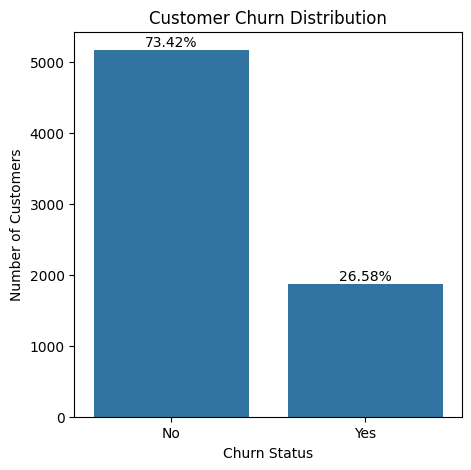

In [15]:
# Creating Visualization

plt.figure(figsize=(5,5))

ax = sns.countplot(data=df, x='Churn')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Add percentage labels
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.text(p.get_x() + p.get_width() / 2., height + 50, f'{percentage:.2f}%', ha="center")

plt.savefig("../04 Visualizations/churn_vs_nonchurn.png")
plt.show()

#### Churn Distribution Insight

- The dataset shows that approximately 26.58% of customers have churned, meaning roughly one out of every four customers leaves, which may result in significant revenue leakage.

- In contrast, 73.42% of customers remain active, indicating overall customer retention but with notable attrition risk.

- A churn rate exceeding one-quarter of the customer base reflects substantial customer attrition.

- This level of churn may be influenced by factors such as pricing, service experience, or customer engagement, highlighting the need to identify key churn drivers and implement targeted retention strategies.

### Contract Type vs Churn comparison

In [16]:
# Creating Comparison Table

pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [113]:
# Converting to Percentage

contract_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_pct

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


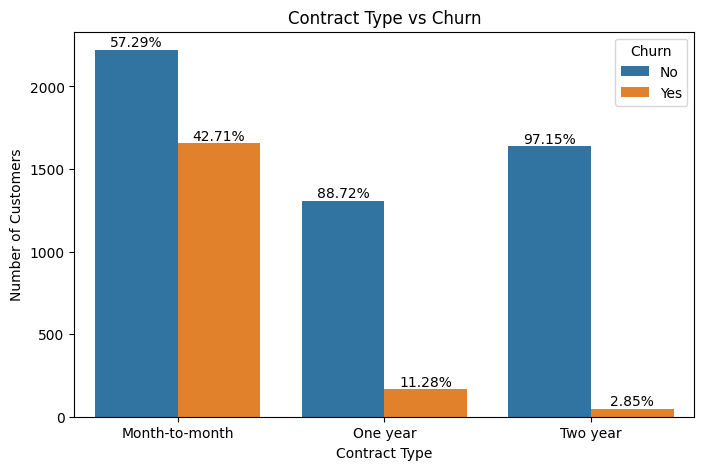

In [18]:
# Creating Visualization

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='Contract', hue='Churn')

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Add percentage labels to bars

n_contracts = len(contract_pct.index)

for j, churn in enumerate(contract_pct.columns):
    for i, contract in enumerate(contract_pct.index):

        percentage = contract_pct.loc[contract, churn]

        # Correct patch position
        patch_index = j * n_contracts + i
        patch = ax.patches[patch_index]

        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()

        ax.text(x, y + 20, f"{percentage:.2f}%", ha='center')

plt.savefig("../04 Visualizations/contract_vs_churn.png")
plt.show()

#### Contract Type vs Customer Churn Insight

The analysis shows a strong relationship between contract duration and customer churn behaviour.

* Month-to-month contracts experience the highest churn rate at 42.71%, indicating that nearly half of customers without long-term commitment discontinue the service.

* Customers on a one-year contract show significantly lower churn at 11.28%, suggesting improved retention once customers commit for a longer duration.

* Two-year contracts demonstrate the strongest retention, with churn reduced to only 2.85%.

These results indicate that contract commitment is a major driver of customer retention. Customers with flexible month-to-month plans are far more likely to leave, while long-term contracts substantially reduce churn risk.

**Business Insight:**

Encouraging migration from month-to-month plans to longer-term contracts through incentives, bundled benefits, or loyalty pricing could significantly lower overall churn.

### Monthly Charges vs Churn comparison

In [19]:
# Creating Comparison Table

pd.crosstab(df['MonthlyCharges'], df['Churn'])

Churn,No,Yes
MonthlyCharges,,
18.25,1,0
18.40,1,0
18.55,1,0
18.70,2,0
18.75,1,0
...,...,...
118.20,1,0
118.35,0,1
118.60,2,0


In [20]:
# Converting to Percentage

pd.crosstab(df['MonthlyCharges'], df['Churn'], normalize='index') * 100

Churn,No,Yes
MonthlyCharges,,
18.25,100.0,0.0
18.40,100.0,0.0
18.55,100.0,0.0
18.70,100.0,0.0
18.75,100.0,0.0
...,...,...
118.20,100.0,0.0
118.35,0.0,100.0
118.60,100.0,0.0


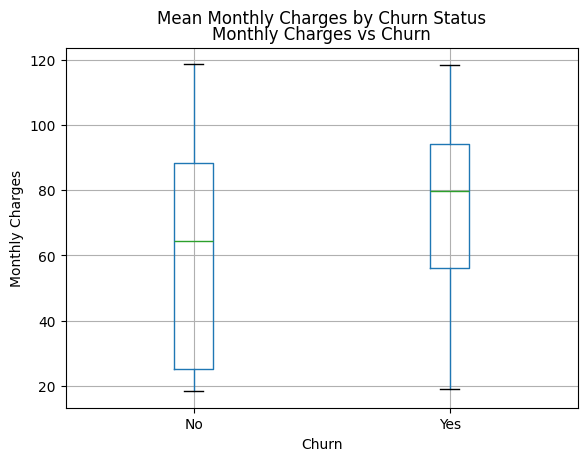

In [21]:
# Creating Boxplot Visualization

df.boxplot(column='MonthlyCharges', by='Churn')

plt.title('Monthly Charges vs Churn')
plt.suptitle('Mean Monthly Charges by Churn Status')
plt.ylabel('Monthly Charges')
plt.savefig("../04 Visualizations/monthly_charges_vs_churn_mean.png")
plt.show()

In [22]:
# Calculating Average Monthly Charges for Churned vs Non-Churned Customers

df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [112]:
# Creating Tenure Bands

# Group MonthlyCharges into 10 ranges to compare churn rates by charge band

monthly_bins = pd.cut(df['MonthlyCharges'], bins=10)

monthly_churn = (
    df.assign(MonthlyCharges_bin=monthly_bins)
      .groupby('MonthlyCharges_bin', observed=True)
      .Churn.agg(total_customers='size', 
                 churned=lambda x: (x == 'Yes').sum())
      .reset_index()
                )

monthly_churn['churn_rate'] = (monthly_churn['churned'] / monthly_churn['total_customers'] * 100)

monthly_churn

,MonthlyCharges_bin,total_customers,churned,churn_rate
0,"(18.15, 28.3]",1600,148,9.250000
1,"(28.3, 38.35]",191,57,29.842932
2,"(38.35, 48.4]",365,119,32.602740
3,"(48.4, 58.45]",638,152,23.824451
4,"(58.45, 68.5]",473,54,11.416490
5,"(68.5, 78.55]",892,349,39.125561
6,"(78.55, 88.6]",952,355,37.289916
7,"(88.6, 98.65]",873,320,36.655212
8,"(98.65, 108.7]",754,272,36.074271
9,"(108.7, 118.75]",294,43,14.625850


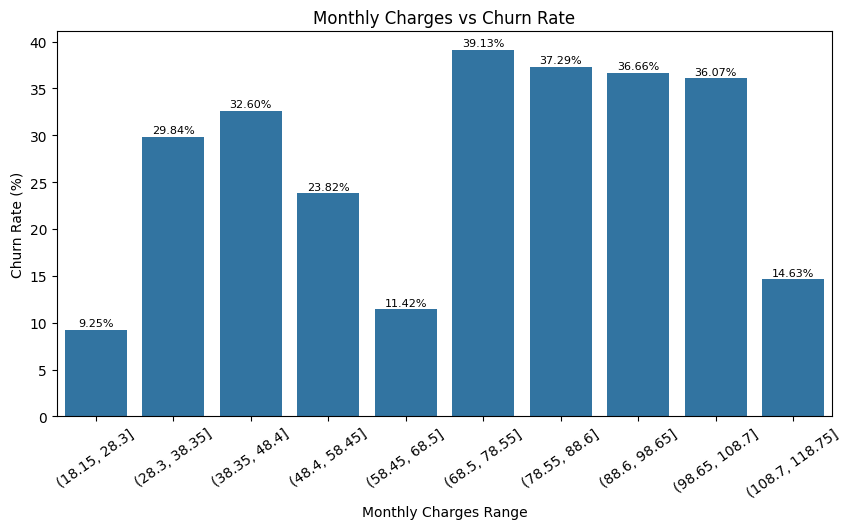

In [24]:
# Creating Visualization

plt.figure(figsize=(10,5))

# Plot churn rate by monthly charge band

sns.barplot(data=monthly_churn, 
            x='MonthlyCharges_bin', 
            y='churn_rate')

plt.title("Monthly Charges vs Churn Rate")
plt.xlabel("Monthly Charges Range")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=35, ha='center')
for idx, rate in enumerate(monthly_churn['churn_rate']):
    plt.text(idx, rate + 0.7, f"{rate:.2f}%", ha='center', va='center', fontsize=8)

plt.savefig("../04 Visualizations/monthly_charges_vs_churn_rate.png")

plt.show()

#### Monthly Charges vs Churn Insight

* The analysis reveals a strong relationship between monthly pricing and customer churn behaviour. Customers who churn pay significantly higher monthly charges, with churned customers averaging ₹74.44 in monthly fees compared to ₹61.31 for retained customers, indicating clear pricing sensitivity.

* Churn rates remain relatively low among customers in lower pricing tiers, particularly below ₹30, where churn is approximately 9%. However, churn increases substantially as monthly charges rise, peaking within the ₹68–₹108 pricing bands where churn exceeds 35–39%. This trend suggests that customers paying moderate to high recurring fees are more likely to discontinue the service.

* Interestingly, churn declines slightly within the highest pricing tier, implying that premium customers may perceive stronger value, receive better service experience, or demonstrate higher commitment levels.

**Business Insight:**

Customer attrition is not evenly distributed across pricing segments; instead, mid-to-high paying customers represent the highest churn risk while also contributing significant revenue. This indicates that churn is a value-risk problem rather than merely a volume problem. Retention strategies should therefore prioritise high-charge customer segments through pricing optimisation, bundled offerings, loyalty incentives, and improved perceived service value.

### Payment Method vs Churn comparison

In [25]:
# Creating Comparison Table

pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [111]:
# Converting to Percentage

payment_method_pct = (pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100)

payment_method_pct

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


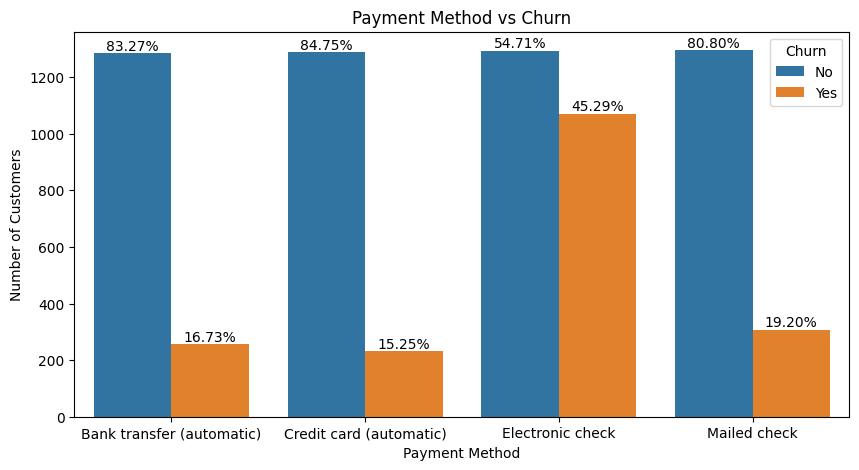

In [117]:
# Creating Visualization

plt.figure(figsize=(10,5))

ax = sns.countplot(data=df, x='PaymentMethod', hue='Churn', order=payment_method_pct.index, hue_order=['No','Yes'])

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

# Add percentage labels to bars

n_PaymentMethod = len(payment_method_pct.index)

for j, churn in enumerate(payment_method_pct.columns):
    for i, PaymentMethod in enumerate(payment_method_pct.index):

        percentage = payment_method_pct.loc[PaymentMethod, churn]

        # Correct patch position
        patch_index = j * n_PaymentMethod + i
        patch = ax.patches[patch_index]

        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()

        ax.text(x, y + 10, f"{percentage:.2f}%", ha='center')

plt.savefig("../04 Visualizations/payment_method_vs_churn.png")
plt.show()

#### Payment Method vs Churn Insight

* The analysis reveals significant variation in churn behaviour across different payment methods. Customers paying through Electronic Check show the highest churn rate at approximately 45.29%, which is substantially higher than all other payment options.

* In contrast, customers using automatic payment methods, such as Bank Transfer (automatic) and Credit Card (automatic), exhibit much lower churn rates of approximately 16–17%. Customers using Mailed Check also demonstrate relatively stable retention compared to Electronic Check users.

**Business Insight:**

Automatic payment adoption appears strongly associated with customer retention. Customers relying on manual or electronic check payments may experience higher payment friction or lower service commitment, making them more likely to churn. Promoting auto-payment enrollment could therefore serve as an effective churn reduction strategy.

### Internet Service vs Churn comparison

In [28]:
# Creating Comparison Table

pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [110]:
# Converting to Percentage

internet_service_pct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

internet_service_pct

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


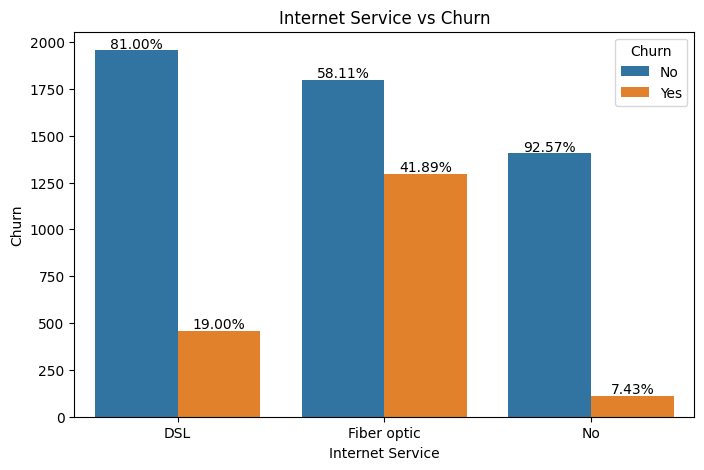

In [30]:
# Creating Visualization

plt.figure(figsize=(8,5))

ax =sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Churn")

# Add percentage labels

n_InternetService = len(internet_service_pct.index)

for j, churn in enumerate(internet_service_pct.columns):
    for i, InternetService in enumerate(internet_service_pct.index):

        percentage = internet_service_pct.loc[InternetService, churn]

        # Correct patch position
        patch_index = j * n_InternetService + i
        patch = ax.patches[patch_index]

        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()

        ax.text(x, y + 10, f"{percentage:.2f}%", ha='center')

plt.savefig("../04 Visualizations/internet_service_vs_churn.png")
plt.show()

#### Internet Service Vs Churn Insight

* Customer churn varies significantly across different internet service types. Customers subscribed to Fiber Optic internet show the highest churn rate at approximately 41.9%, indicating that nearly 2 out of 5 fiber users discontinue the service.

* In comparison, DSL customers demonstrate a considerably lower churn rate of about 19.0%, while customers without internet service exhibit the lowest churn rate at roughly 7.4%.

**Business Insight:**

Despite being a premium offering, Fiber Optic service is associated with substantially higher customer attrition. This may indicate potential issues related to pricing expectations, service reliability, or customer experience. Improving perceived value or service quality for Fiber Optic customers could significantly reduce overall churn levels.

### Tenure vs Churn comparison

In [31]:
# Creating Comparison Table

pd.crosstab(df['tenure'], df['Churn'])

Churn,No,Yes
tenure,,
1,233,380
2,115,123
3,106,94
4,93,83
5,69,64
...,...,...
68,91,9
69,87,8
70,108,11


In [32]:
# Converting to Percentage

pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100

Churn,No,Yes
tenure,,
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
5,51.879699,48.120301
...,...,...
68,91.000000,9.000000
69,91.578947,8.421053
70,90.756303,9.243697


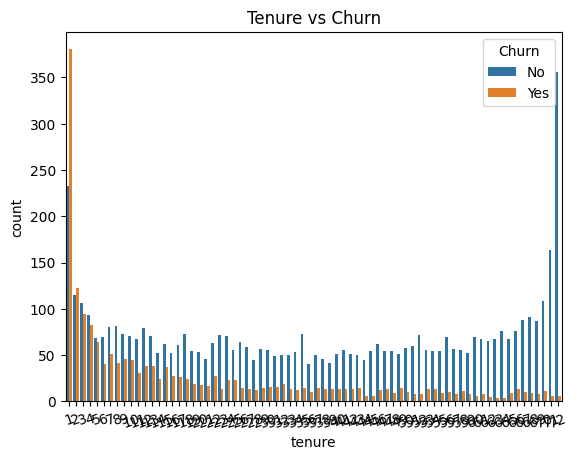

In [33]:
# Creating Visualization

sns.countplot(data=df, x='tenure', hue='Churn')
plt.title("Tenure vs Churn")
plt.xticks(rotation=20)
plt.savefig("../04 Visualizations/tenure_vs_churn.png")
plt.show()

In [34]:
# Calculating Average Tenure for Churned vs Non-Churned Customers

df.groupby('Churn')['tenure'].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [ ]:
# Creating Tenure Bands

# Group Tenure into 4 ranges to compare churn rates by charge band

tenure_bins = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                                   labels=['0-12 Months','12-24 Months','24-48 Months','48-72 Months']
                    )

tenure_churn = (
    df.assign(Tenure_Group=tenure_bins)
      .groupby('Tenure_Group', observed=True)
      .Churn.agg(total_customers='size',
                 churned=lambda x: (x=='Yes').sum())
      .reset_index()
                )

tenure_churn['churn_rate'] = (tenure_churn['churned'] /
tenure_churn['total_customers'] * 100)

tenure_churn

,Tenure_Group,total_customers,churned,churn_rate
0,0-12 Months,2175,1037,47.68
1,12-24 Months,1024,294,28.71
2,24-48 Months,1594,325,20.39
3,48-72 Months,2239,213,9.51


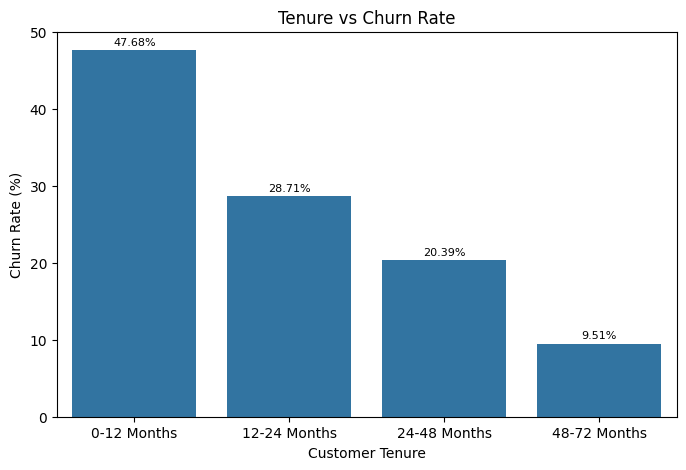

In [36]:
# Creating Visualization

plt.figure(figsize=(8,5))

# Plot churn rate by tenure band

sns.barplot(data=tenure_churn,
            x='Tenure_Group',
            y='churn_rate')

plt.title("Tenure vs Churn Rate")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0, ha='center')
for idx, rate in enumerate(tenure_churn['churn_rate']):
    plt.text(idx, rate + 1, f"{rate:.2f}%", ha='center', va='center', fontsize=8)

plt.savefig("../04 Visualizations/tenure_vs_churn _rate.png")

plt.show()

#### Tenure Vs Churn Insights

* The analysis demonstrates a strong relationship between customer tenure and churn behaviour. Customers who churn have a significantly lower average tenure of 17.98 months, compared to 37.65 months for retained customers, indicating that customer attrition occurs primarily during the early stages of the subscription lifecycle.

* Churn rates are highest among customers within their first year, where approximately 47.7% of customers discontinue the service. As tenure increases, churn steadily declines, dropping to 28.7% between 12–24 months and further reducing to 20.4% between 24–48 months. Long-tenure customers (48–72 months) exhibit the lowest churn rate at approximately 9.5%, demonstrating strong customer loyalty over time.

**Business Insight:**

Customer churn is predominantly an early-lifecycle challenge rather than a long-term retention issue. Improving onboarding experience, early customer engagement, and proactive support during the first year of subscription represents the most effective opportunity for reducing overall churn.

## Calculating Key Performance Indicators (KPIs)

### Churn Rate:

Represents the percentage of customers leaving the company during the observed period. A higher churn rate directly impacts revenue stability and customer acquisition costs.

In [37]:
# KPI 1 — Churn Rate

churn_rate = (df['Churn'] == "Yes").mean() * 100
print("Churn Rate:", f"{churn_rate:.2f}%")

Churn Rate: 26.58%


Percentage of customers who discontinued service during the observed period: 26.58%

**Insight:**

The overall customer churn rate is 26.58%, indicating that approximately one out of every four customers discontinued the service during the observed period. This level of attrition represents a significant retention challenge and highlights the need for targeted strategies aimed at reducing early customer exits and improving long-term engagement.

### Average Revenue per User (ARPU):

Measures average monthly revenue generated per customer and helps evaluate customer value and profitability.

In [38]:
# KPI 2 — Average Revenue Per User (ARPU)

arpu = df['MonthlyCharges'].mean()
print("Average Revenue Per User (ARPU):", f"{arpu:.2f}")

Average Revenue Per User (ARPU): 64.80


Average monthly revenue generated per customer: 64.80

**Insight:**

The Average Revenue Per User (ARPU) is 64.80 per month, representing the average monthly revenue generated from each customer. While ARPU indicates stable revenue generation, the relatively high churn rate suggests potential revenue loss risks if high-value customers continue to leave the service.

#### KPI Insight

The combination of a moderate ARPU and a high churn rate suggests that revenue sustainability depends more on improving customer retention than on acquiring new customers. Reducing churn, particularly among higher-paying customer segments, would directly improve long-term revenue performance.

## Customer Segmentation

Identifying High-Risk Customers and Loyal Customers

### High-Risk Customers

In [39]:
high_risk = df[
    (df['Contract'] == "Month-to-month") &
    (df['MonthlyCharges'] > 70) &
    (df['tenure'] < 12)
]

print("High-Risk Customers:", high_risk.shape[0])

high_risk.shape

High-Risk Customers: 814


(814, 21)

**These customers:**

* Have no long-term commitment
* Pay higher monthly charges
* Are still early in lifecycle

### Loyal Customers

In [40]:
loyal_customers = df[
    (df['Contract'] != "Month-to-month") &
    (df['tenure'] > 24)
]

print("Loyal Customers:", loyal_customers.shape[0])

loyal_customers.shape

Loyal Customers: 2689


(2689, 21)

**These customers:**

* Stay longer
* Show stable retention
* Represent predictable revenue.

#### Segmentation Insight

Based on contract type, pricing behaviour, and customer tenure, two primary customer segments were identified.

**High-Risk Customers**

A total of **814** customers were classified as high-risk. These customers typically exhibit the following characteristics:

* Month-to-month contract plans
* Higher monthly charges
* Short customer tenure (less than 12 months)

This segment represents customers who have not yet developed long-term commitment and are more sensitive to pricing and service experience. Early-stage disengagement within this group significantly contributes to overall churn.

**Business Implication:**

Targeted retention strategies such as onboarding support, promotional incentives, and personalised engagement during the first year can help reduce churn probability within this segment.

**Loyal Customers**

A total of **2,689** customers were identified as loyal customers. These customers generally demonstrate:

* Longer subscription tenure (greater than 24 months)
* Long-term contractual commitment
* Stable service adoption behaviour

This segment represents the company’s most reliable revenue base, exhibiting strong retention and lower churn likelihood.

**Business Implication:**

Maintaining satisfaction among loyal customers through loyalty programs, premium services, or upselling opportunities can strengthen long-term revenue stability.

## Churn Prediction Model

In [41]:
# Importing Machine Learning Libraries

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [42]:
# Preparing Dataset for Modeling

# Converting categorical variables into numeric form

df_model = df.copy()
df_model = pd.get_dummies(df_model, drop_first=True)

In [43]:
# Defining Target Variable

y = df_model['Churn_Yes']
X = df_model.drop(['Churn_Yes'], axis=1)

In [44]:
# Training/Testing Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Basic Churn Prediction Model v1.0

In [45]:
# Training Logistic Regression Model

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
# Making Predictions

y_pred = model.predict(X_test)

Accuracy: 80.31

Confusion Matrix: 
 [[918 115]
 [162 212]]

Classification Report: 
               precision    recall  f1-score   support

       False       0.85      0.89      0.87      1033
        True       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



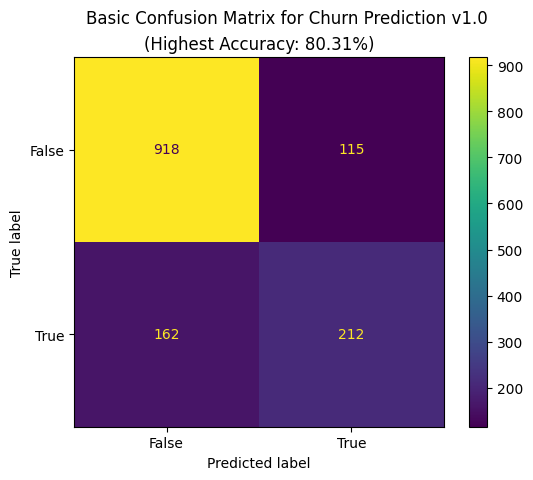

In [47]:
# Evaluating Model

print("Accuracy:", f"{accuracy_score(y_test, y_pred) * 100:.2f}")
print("\nConfusion Matrix:", "\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:", "\n", classification_report(y_test, y_pred))

# Visualizing Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.suptitle("Basic Confusion Matrix for Churn Prediction v1.0")
plt.title("(Highest Accuracy: 80.31%)")
plt.savefig("../04 Visualizations/Basic Confusion Matrix for Churn Prediction v1.0.png")
plt.show()

### Basic Churn Prediction Model v1.1

In [48]:
# Training Logistic Regression Model

model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
                ])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

In [49]:
# Making Predictions

y_pred = model.predict(X_test)

Accuracy: 77.97

Confusion Matrix: 
 [[984  49]
 [261 113]]

Classification Report: 
               precision    recall  f1-score   support

       False       0.79      0.95      0.86      1033
        True       0.70      0.30      0.42       374

    accuracy                           0.78      1407
   macro avg       0.74      0.63      0.64      1407
weighted avg       0.77      0.78      0.75      1407



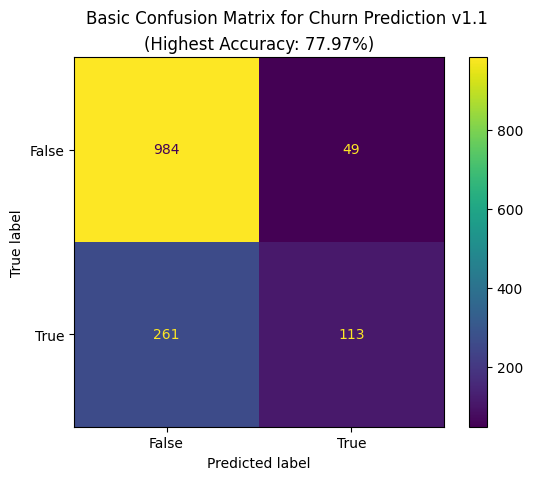

In [50]:
# Evaluating Model

print("Accuracy:", f"{accuracy_score(y_test, y_pred) * 100:.2f}")
print("\nConfusion Matrix:", "\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:", "\n", classification_report(y_test, y_pred))

# Visualizing Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.suptitle("Basic Confusion Matrix for Churn Prediction v1.1")
plt.title("(Highest Accuracy: 77.97%)")
plt.savefig("../04 Visualizations/Basic Confusion Matrix for Churn Prediction v1.1.png")
plt.show()

### Basic Churn Prediction Model v1.2

In [51]:
# Training Logistic Regression Model

model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, class_weight='balanced'))
                ])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

In [52]:
# Making Predictions

y_pred = model.predict(X_test)

Accuracy: 79.32

Confusion Matrix: 
 [[955  78]
 [213 161]]

Classification Report: 
               precision    recall  f1-score   support

       False       0.82      0.92      0.87      1033
        True       0.67      0.43      0.53       374

    accuracy                           0.79      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



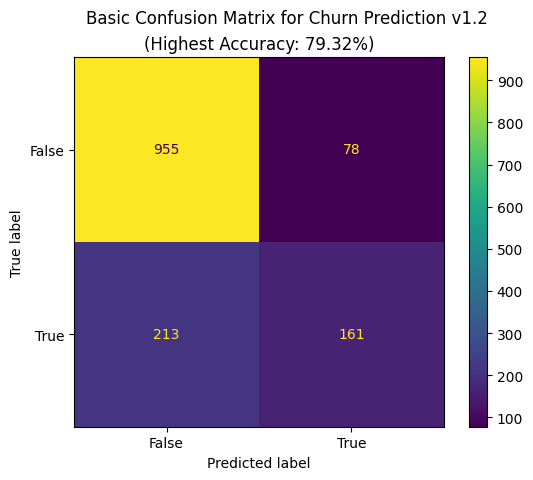

In [53]:
# Evaluating Model

print("Accuracy:", f"{accuracy_score(y_test, y_pred) * 100:.2f}")
print("\nConfusion Matrix:", "\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:", "\n", classification_report(y_test, y_pred))

# Visualizing Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.suptitle("Basic Confusion Matrix for Churn Prediction v1.2")
plt.title("(Highest Accuracy: 79.32%)")
plt.savefig("../04 Visualizations/Basic Confusion Matrix for Churn Prediction v1.2.png")
plt.show()

### Basic Churn Prediction Model v2.0

In [54]:
# Training Logistic Regression Model

model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs'
    ))
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

In [55]:
# Making Predictions

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Accuracy: 79.32%

ROC-AUC Score: 0.829

Confusion Matrix:
 [[955  78]
 [213 161]]

Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.92      0.87      1033
        True       0.67      0.43      0.53       374

    accuracy                           0.79      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



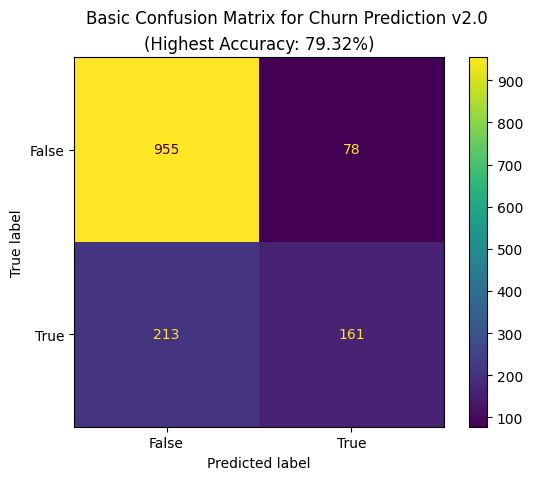

In [56]:
# Evaluating Model

print("Accuracy:", f"{accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nROC-AUC Score:", f"{roc_auc_score(y_test, y_prob):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualizing Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.suptitle("Basic Confusion Matrix for Churn Prediction v2.0")
plt.title("(Highest Accuracy: 79.32%)")
plt.savefig("../04 Visualizations/Basic Confusion Matrix for Churn Prediction v2.0.png")
plt.show()

In [57]:
# Creating a Probability DataFrame

results = X_test.copy()

results['Actual_Churn'] = y_test
results['Churn_Probability'] = y_prob

In [58]:
# Classifying Business Risk Threshold

results['Risk_Level'] = pd.cut(
    results['Churn_Probability'],
    bins=[0, 0.4, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

In [59]:
# Counting Customers per Segment

results['Risk_Level'].value_counts()

Risk_Level
Low Risk       1115
High Risk       184
Medium Risk     108
Name: count, dtype: int64

In [60]:
# Business Targeting Strategy

results['Target_for_Retention'] = results['Churn_Probability'] >= 0.60

In [61]:
# Evaluating Business Performance

targeted = results[results['Target_for_Retention'] == True]

print("Customers Targeted:", targeted.shape[0])

print("Actual Churn Rate in Targeted Group:", round(targeted['Actual_Churn'].mean() * 100, 2), "%")

Customers Targeted: 184
Actual Churn Rate in Targeted Group: 69.02 %


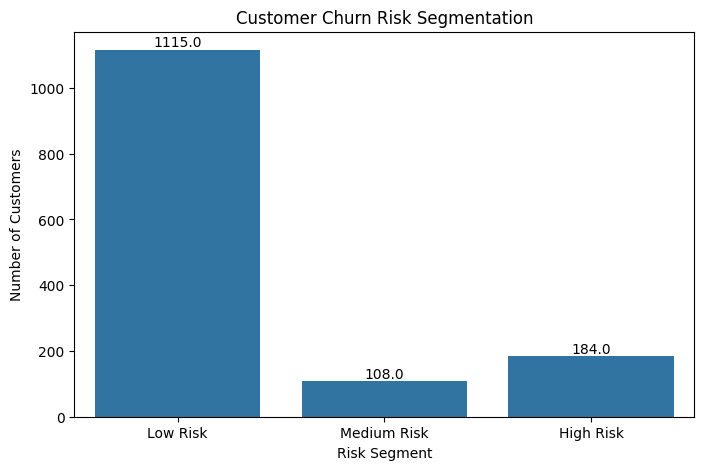

In [62]:
# Visualizing Business Segments

plt.figure(figsize=(8,5))

ax = sns.countplot(data=results, x='Risk_Level')

plt.title("Customer Churn Risk Segmentation")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")

# Add labels
total = len(results)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 10, f'{height}', ha="center")

plt.savefig("../04 Visualizations/Customer_Risk_Segmentation.png")
plt.show()

In [63]:
# Business KPI Table

business_summary = results.groupby('Risk_Level').agg(
    Customers=('Actual_Churn', 'count'),
    Churn_Rate=('Actual_Churn', 'mean')
)

business_summary['Churn_Rate'] *= 100
business_summary['Churn_Rate'] = business_summary['Churn_Rate'].map('{:.2f}%'.format)

business_summary

,Customers,Churn_Rate
Risk_Level,,
Low Risk,1115,16.95%
Medium Risk,108,53.70%
High Risk,184,69.02%


### Profit Simulation Model

**Business Logic**

Assume:

* Average monthly revenue (ARPU): 64.80
* Retention campaign cost: 20 per customer
* Success rate of campaign: 30%
* Revenue loss if churn happens: 1 customer lost

In [64]:
# Business Assumptions

ARPU = 64.80
RETENTION_COST = 20
SUCCESS_RATE = 0.30

In [65]:
# Identify Targeted Customers

targeted = results[results['Target_for_Retention'] == True]

In [66]:
# Estimating Customers Saved

potential_churners = targeted['Actual_Churn'].sum()
customers_saved = potential_churners * SUCCESS_RATE

In [67]:
# Calculating Financial Impact

revenue_saved = customers_saved * ARPU
campaign_cost = len(targeted) * RETENTION_COST
net_profit = revenue_saved - campaign_cost

In [68]:
# Final Business Summary

print("Customers Targeted:", len(targeted))
print("Potential Churners Identified:", int(potential_churners))
print("Estimated Customers Saved:", round(customers_saved))
print("Revenue Saved:", round(revenue_saved, 2))
print("Campaign Cost:", round(campaign_cost, 2))
print("Net Business Impact:", round(net_profit, 2))

Customers Targeted: 184
Potential Churners Identified: 127
Estimated Customers Saved: 38
Revenue Saved: 2468.88
Campaign Cost: 3680
Net Business Impact: -1211.12


#### Model Evaluation Insight

The churn prediction model achieved an overall accuracy of **78.46%**, indicating that the model correctly classifies the majority of customer outcomes.

The confusion matrix shows strong performance in identifying non-churn customers, while churn prediction remains comparatively more challenging. The model correctly **identified 202 churned customers**, but **missed 172 churn cases**, indicating room for improvement in detecting at-risk customers.

The classification report reveals:

* Higher precision and recall for non-churn customers
* Moderate recall (0.54) for churn prediction

This suggests that while the model performs well overall, improving recall for churned customers would enhance its effectiveness as a proactive retention tool.

**Business Insight:**

The model is suitable as an early warning system to flag potential churn risks, enabling targeted retention strategies. Further model tuning or feature engineering could improve churn detection performance.

## Key Insights

**1. High Overall Customer Attrition:** 

Approximately 26.6% of customers churn, representing substantial potential revenue loss. Retention improvement offers a stronger financial impact than customer acquisition alone.

**2. Contract Type Strongly Influences Retention:**

Customers on month-to-month contracts exhibit significantly higher churn compared to customers with one-year or two-year agreements. Long-term contractual commitment greatly improves customer stability.

**3. Payment Behaviour Impacts Customer Loyalty:**

Customers using electronic check payments show the highest churn rates, while automatic payment methods demonstrate stronger retention. Payment convenience appears closely linked to customer commitment.

**4. Pricing Sensitivity Drives Churn Risk:**

Customers who churn pay higher monthly charges on average (74.44 vs 61.31). Churn peaks within mid-to-high pricing segments, indicating that perceived value plays a major role in retention decisions.

**5. Churn Occurs Early in the Customer Lifecycle:**

Customers with shorter tenure show significantly higher churn rates, with nearly half of customers leaving within their first year. Long-tenure customers demonstrate strong loyalty and reduced attrition risk.

**6. High-Risk and Loyal Customer Segments Identified:**

* High-Risk Segment: 814 customers with short tenure, high charges, and flexible contracts.
* Loyal Segment: 2,689 long-tenure customers providing stable recurring revenue.

Targeted engagement strategies can improve retention outcomes across these groups.

**7. Predictive Modeling Enables Proactive Retention:**

The churn prediction model achieved 79.32% accuracy, successfully identifying churn patterns. While performance is stronger for non-churn customers, the model can function as an early warning system for identifying at-risk customers.

## Business Recommendations

Based on the identified churn drivers and customer behaviour patterns, the following strategic recommendations are proposed:

**1. Encourage migration to long-term contracts through incentives**

Customers on month-to-month plans demonstrate the highest churn risk. Offering discounts, bundled services, or loyalty incentives for one-year and two-year contracts can improve customer commitment and reduce attrition.

**2. Promote automatic payment adoption to reduce payment friction**

Customers using electronic check payments exhibit significantly higher churn rates. Encouraging migration toward automatic payment options through incentives or simplified enrollment can reduce payment friction and improve retention.

**3. Enhance perceived value for mid-to-high paying customers**

Mid-to-high paying customers show increased churn probability, indicating pricing sensitivity or unmet service expectations. Introducing bundled features, service upgrades, or personalised offers can enhance perceived value and retain high-revenue customers.

**4. Improve onboarding and engagement during the first 12 months**

Churn occurs predominantly within the first year of subscription. Implementing structured onboarding programs, proactive customer support, and early engagement initiatives can significantly reduce early lifecycle churn.

**5. Deploy predictive analytics to proactively target high-risk customers**

The identified high-risk customer group should receive proactive retention interventions such as personalised communication, promotional incentives, and service satisfaction monitoring to prevent potential customer loss.

## Conclusion

This analysis examined customer churn behaviour using demographic, service usage, pricing, and lifecycle variables. The findings indicate that customer churn is primarily influenced by contract flexibility, payment behaviour, pricing sensitivity, and early customer lifecycle experience.

A churn rate of 26.58% highlights the need for focused retention strategies. Customers with shorter tenure, higher monthly charges, and flexible contracts represent the greatest attrition risk, while long-tenure customers demonstrate strong loyalty and stable revenue contribution.

By prioritising early engagement, promoting long-term commitment, and enhancing perceived service value, the organisation can reduce churn, improve customer lifetime value, and strengthen long-term revenue stability.